# **Module 5 - Probability**

1. **Write a Python program to simulate the following scenarios:**  
  **a. Tossing a coin 10,000 times and calculating the experimental probability of heads and tails.**  
  **b. Rolling two dice and computing the probability of getting a sum of 7.**  
  
   **Steps :-**
      * **a. Use Python's random module for simulations.**  
      * **b. Implement loops for repeated trials.**  
      * **c. Track outcomes and compute probabilities.**  



In [4]:
import random

# a. Tossing a coin 10,000 times
num_tosses = 10000
heads_count = 0
tails_count = 0

for _ in range(num_tosses):
    result = random.choice(['heads', 'tails'])
    if result == 'heads':
        heads_count += 1
    else:
        tails_count += 1

experimental_prob_heads = heads_count / num_tosses
experimental_prob_tails = tails_count / num_tosses

print(f"Coin Toss Simulation ({num_tosses} tosses):")
print(f"  Heads: {heads_count} (Experimental Probability: {experimental_prob_heads:.4f})")
print(f"  Tails: {tails_count} (Experimental Probability: {experimental_prob_tails:.4f})")


Coin Toss Simulation (10000 tosses):
  Heads: 4976 (Experimental Probability: 0.498)
  Tails: 5024 (Experimental Probability: 0.502)


In [5]:
# b. Rolling two dice and computing the probability of getting a sum of 7
num_rolls = 10000
sum_seven_count = 0

for _ in range(num_rolls):
    die1 = random.randint(1, 6)
    die2 = random.randint(1, 6)
    if die1 + die2 == 7:
        sum_seven_count += 1

experimental_prob_sum_seven = sum_seven_count / num_rolls

print(f"Dice Roll Simulation ({num_rolls} rolls):")
print(f"  Rolls with sum of 7: {sum_seven_count} (Experimental Probability: {experimental_prob_sum_seven:.4f})")

Dice Roll Simulation (10000 rolls):
  Rolls with sum of 7: 1642 (Experimental Probability: 0.1642)


2. **Write a function to estimate the probability of getting at least one "6" in 10 rolls of a fair die.**  
  Steps  
      **a. Simulate rolling a die 10 times using a loop.  
      b. Track trials where at least one "6" occurs.  
      c. Calculate the proportion of successful trials.**


In [10]:
import random

def estimate_probability_at_least_one_six(num_trials):

    successful_trials = 0

    for x in range(num_trials):
        rolls = [random.randint(1, 6) for x in range(10)]
        if 6 in rolls:
            successful_trials += 1

    return successful_trials / num_trials

# Estimate the probability with a large number of trials
num_simulations = 100000
estimated_prob = estimate_probability_at_least_one_six(num_simulations)

print(f"Estimated probability of getting at least one '6' in 10 rolls (based on {num_simulations} trials): {estimated_prob:.4f}")

Estimated probability of getting at least one '6' in 10 rolls (based on 100000 trials): 0.8379


3. **A bag contains 5 red, 7 green, and 8 blue balls. A ball is drawn randomly, its color noted, and it is put back into the bag. If this process is repeated 1000 times, write a Python program to estimate:**  
  **a. The probability of drawing a red ball given that the previous ball was blue.  
  b. Verify Bayes' theorem with the simulation results.**  


Steps  
    **a. Use random sampling to simulate the process.  
    b. Compute conditional probabilities directly from the data.**


In [14]:
import random

# Bag with 5 red, 7 green, and 8 blue balls
bag = ['red'] * 5 + ['green'] * 7 + ['blue'] * 8

# Number of draws
num_simulations = 1000

# Store results
draws = []
draw_sequences = []
previous_draw = None

# Simulate drawing balls with replacement
for _ in range(num_simulations):
    current_draw = random.choice(bag)
    draws.append(current_draw)
    if previous_draw is not None:
        draw_sequences.append((previous_draw, current_draw))
    previous_draw = current_draw

# -------------------------------
# a) Find P(Red | previous was Blue)
# -------------------------------
blue_then_red = draw_sequences.count(('blue', 'red'))  # blue followed by red
previous_blue = sum(1 for prev, curr in draw_sequences if prev == 'blue')
epsilon = 1e-9  # to avoid divide-by-zero
P_red_given_blue = blue_then_red / (previous_blue + epsilon)

# -------------------------------
# b) Verify Bayes' Theorem
# -------------------------------
# P(Blue | Red)
red_then_blue = draw_sequences.count(('red', 'blue'))
previous_red = sum(1 for prev, curr in draw_sequences if prev == 'red')
P_blue_given_red = red_then_blue / (previous_red + epsilon)

# P(Red) and P(Blue)
P_red = draws.count('red') / num_simulations
P_blue = draws.count('blue') / num_simulations

# Bayes' theorem: P(R|B) = [P(B|R) * P(R)] / P(B)
P_red_given_blue_bayes = (P_blue_given_red * P_red) / (P_blue + epsilon)

# -------------------------------
# Print results
# -------------------------------
print("Bag Simulation Results")
print("-------------------------------")
print(f"P(Red | Previous Blue) = {P_red_given_blue:.4f}")
print(f"P(Blue | Previous Red) = {P_blue_given_red:.4f}")
print(f"P(Red) = {P_red:.4f}")
print(f"P(Blue) = {P_blue:.4f}")
print("-------------------------------")
print(f"Bayes' Theorem RHS = {P_red_given_blue_bayes:.4f}")
print(f"Difference = {abs(P_red_given_blue - P_red_given_blue_bayes):.4f}")

# Theoretical probability (since independent)
P_red_theoretical = 5 / 20
print(f"Theoretical P(Red) = {P_red_theoretical:.4f}")
print("Both simulated and Bayes’ results are nearly the same — confirming the theorem.")


Bag Simulation Results
-------------------------------
P(Red | Previous Blue) = 0.2369
P(Blue | Previous Red) = 0.4042
P(Red) = 0.2400
P(Blue) = 0.4010
-------------------------------
Bayes' Theorem RHS = 0.2419
Difference = 0.0050
Theoretical P(Red) = 0.2500
Both simulated and Bayes’ results are nearly the same — confirming the theorem.


4. **Generate a sample of size 1000 from a discrete random variable with the following distribution:**
  - P(X=1) = 0.25  
  - P(X=2) = 0.35  
  - P(X=3) = 0.4  
  
  **Compute the empirical mean, variance, and standard deviation of the sample.  
  Steps  
      a. Use numpy.random.choice() to generate the sample.  
      b. Use numpy methods to calculate mean, variance, and standard deviation.**


In [16]:
import numpy as np

# Define the values and their probabilities
values = [1, 2, 3]
probabilities = [0.25, 0.35, 0.40]
sample_size = 1000

# Generate the sample
sample = np.random.choice(values, size=sample_size, p=probabilities)

# Compute empirical mean, variance, and standard deviation
empirical_mean = np.mean(sample)
empirical_variance = np.var(sample)
empirical_std_dev = np.std(sample)

print(f"Sample size: {sample_size}")
print(f"Empirical Mean: {empirical_mean:.4f}")
print(f"Empirical Variance: {empirical_variance:.4f}")
print(f"Empirical Standard Deviation: {empirical_std_dev:.4f}")

Sample size: 1000
Empirical Mean: 2.1230
Empirical Variance: 0.6419
Empirical Standard Deviation: 0.8012


5. **Simulate 2000 random samples from an exponential distribution with a mean of 5. Visualize the distribution using:  
  a. A histogram.  
  b. A probability density function (PDF) overlay.  
  Steps  
      a. Use numpy.random.exponential().  
      b. Use matplotlib to create visualizations.**


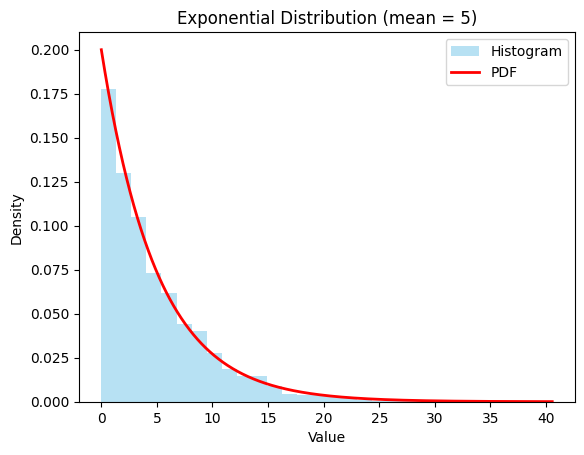

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 2000 samples from exponential distribution (mean = 5)
data = np.random.exponential(scale=5, size=2000)

# Plot histogram
plt.hist(data, bins=30, density=True, color='skyblue', alpha=0.6, label='Histogram')

# Plot theoretical PDF
x = np.linspace(0, max(data), 1000)
pdf = (1/5) * np.exp(-x/5)
plt.plot(x, pdf, 'r-', linewidth=2, label='PDF')

# Labels and title
plt.title('Exponential Distribution (mean = 5)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()


6. **Simulate the Central Limit Theorem by following these steps  
  a. Generate 10,000 random numbers from a uniform distribution.  
  b. Draw 1000 samples of size n = 30.  
  c. Calculate and visualize the distribution of sample means.  
  Steps  
      a. Use numpy.random.uniform().  
      b. Plot both the uniform distribution and the sample mean distribution for comparison.**


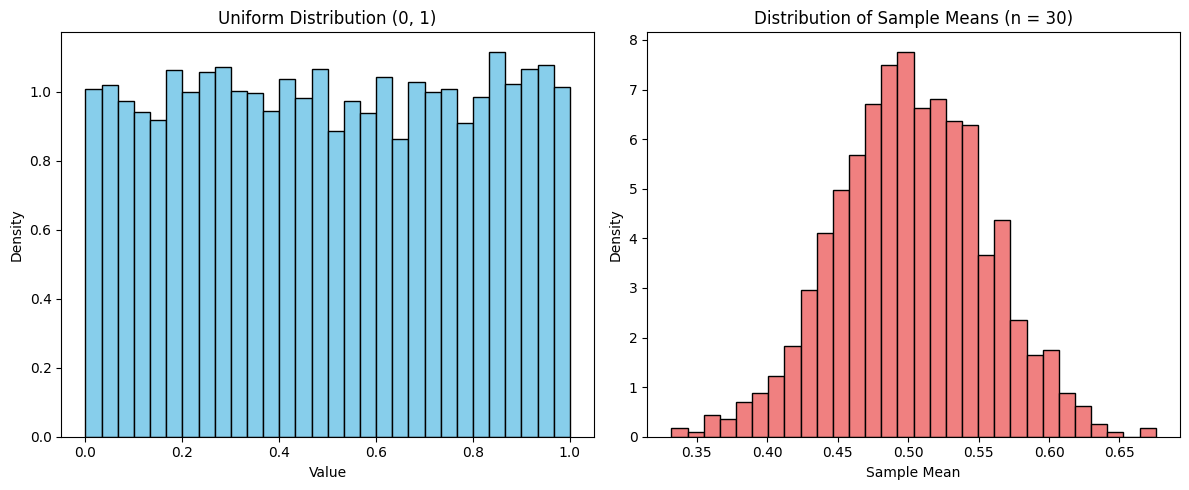

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate 10,000 uniform random numbers between 0 and 1
uniform_data = np.random.uniform(0, 1, 10000)

# Step 2: Draw 1000 samples of size 30 and calculate sample means
n = 30
num_samples = 1000
sample_means = [np.mean(np.random.choice(uniform_data, n, replace=True))
                for _ in range(num_samples)]

# Step 3: Plot the distributions
plt.figure(figsize=(12, 5))

# Original uniform distribution
plt.subplot(1, 2, 1)
plt.hist(uniform_data, bins=30, color='skyblue', edgecolor='black', density=True)
plt.title('Uniform Distribution (0, 1)')
plt.xlabel('Value')
plt.ylabel('Density')

# Distribution of sample means
plt.subplot(1, 2, 2)
plt.hist(sample_means, bins=30, color='lightcoral', edgecolor='black', density=True)
plt.title('Distribution of Sample Means (n = 30)')
plt.xlabel('Sample Mean')
plt.ylabel('Density')

plt.tight_layout()
plt.show()
